In [1]:
from pyfmreader.ps_nex.parseTDMS import get_channel_names, parse_tdms

In [2]:
file = '/Users/evillz/Data/psnex_map___2025.03.12_18.23.11.20.map/fcurve___2025.03.12_18.25.44.81.tdms'
# file = '/Users/evillz/Data/psnex_map___2025.03.12_18.23.11.20/fcurve___2025.03.12_18.23.29.39.tdms' #Fast approach  
# file = '/Users/evillz/Data/psnex_map___2024.10.15_16.31.06.47/fcurve___2024.10.15_16.36.20.28.tdms' # fast approach
# file = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.38.42.45/fcurve___2025.03.12_18.49.42.45.tdms'



In [3]:
# fast approach long range demonstration 
# file = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.38.42.45/fcurve___2025.03.12_18.47.16.88.tdms'

In [4]:
# Latest files 
# file = '/Users/evillz/Data/article/2025_12_06/1bead/psnex_map___2025.06.12_18.06.36.23/fcurve___2025.06.12_18.06.42.65.tdms'
file = '/Users/evillz/Data/article/2025_12_06/glass/fcurve_Glass_10um__2025.06.12_16.11.17.92.tdms'
file = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/fcurve___2025.05.30_17.48.59.79.tdms'


In [5]:
# article
# file = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/fcurve___2025.05.30_18.05.48.47.tdms'
# file = '/Users/evillz/Data/article/2025_30_5/fcurve___2025.05.30_18.17.35.76.tdms'

In [6]:
# # Slow approach example 
# file = '/Users/evillz/Data/article/2025_30_5/psnex_map__curves/fcurve___2025.05.30_18.14.38.08.tdms'

# file = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_18.20.42.80/fcurve___2025.05.30_18.21.47.76.tdms'

# file = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/fcurve___2025.05.30_17.50.46.00.tdms'




In [7]:
from pyfmreader.plotting import load_fcurve_metadata, smooth_derivative


metadata, piezo_um, deflection_zero_N, time_s = load_fcurve_metadata(file)

⚠️  Missing metadata key: 'mapping_X_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_Y_pixel' - using default: 0
All segments have decimation factors: 10, 10, 10


In [8]:
# time_s, piezo_um,
import numpy as np

piezo_deriv = np.gradient(piezo_um, time_s)  # Calculate the derivative of piezo_um with respect to time_s
deriv_piezo_smooth = smooth_derivative(piezo_um, time_s, window_size=100)

In [9]:
CheckMapfiles = False

if CheckMapfiles:
    import pyfmreader.ps_nex.loadpsnexMaps as maps
    map_path = '/Users/evillz/Data/article/2025_30_5'
    df_point_log = maps.checkMapFileNULL(map_path)

In [10]:


channels = get_channel_names(file)
for channel in channels:
    print(channel)
channel_data_deflection, channel_data_piezo, channel_time = parse_tdms(file, deflectionChannel=channels[0][0], zDisplacement=channels[0][1])

{0: 'Deflection_quotient_(V)', 1: 'Zpiezo_stage_sensor_(V)'}
Force Curve
2.0


In [11]:
from pyfmreader import loadfile
file_meta = loadfile(file)
metadata= file_meta.filemetadata
curve_index = 0


dec_app = int(metadata['curve_properties']['0'][0]['segment_0_dec_factor'])
dec_con = int(metadata['curve_properties']['0'][1]['segment_1_dec_factor'])
dec_ret = int(metadata['curve_properties']['0'][2]['segment_2_dec_factor'])
num_segment_arr = metadata['num_segments']


app_vel_v_tick = float(metadata['curve_properties']['0'][0]['segment_0_velocity(V/tick)'])
ret_vel_v_tick = float(metadata['curve_properties']['0'][2]['segment_2_velocity(V/tick)'])


if dec_app and dec_con and dec_ret:
    print(f'All segments have decimation factors: {dec_app}, {dec_con}, {dec_ret}')

#check if all decimation is the same
decimation_factor = metadata['curve_properties']['0'][0]['segment_0_dec_factor']
# metadata['curve_properties']['0'][0]


⚠️  Missing metadata key: 'mapping_X_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_Y_pixel' - using default: 0
All segments have decimation factors: 10, 10, 10


In [12]:
from pyfmreader.ps_nex.parsepsnexheader import parsePSNEXheader


file_metadata = parsePSNEXheader(file)

fs = file_meta.filemetadata['curve_properties']['0'][0]['segment_0_sampling_rate_(S/s)']
tick_time_s = file_meta.filemetadata['curve_properties']['0'][0]['tick_time_s']
tick_time_z_loop = 2e-6 #500Khz
# metadata = file.metadata
# fs = 500e3
dt = 1/fs

relative_sr = (dt / decimation_factor) / tick_time_s
# get sensitivities for Z calibration
z_sens_um_v = float(file_meta.filemetadata['curve_properties']['0'][0]['z_stage_sensitivity'])/1e3
k = float(file_metadata['cantilever_spring_constant_calib_N/m']) # N/m
invols_m_v = float(file_metadata['invOLS_(nm/V)']) * 1e-9 # nm/V

#% calculate velocty 

# app_um_s = app_vel_v_tick * (0.025e-6 * 80) 
app_um_s = app_vel_v_tick / (tick_time_z_loop / decimation_factor) * (z_sens_um_v *1e-6)
print (f'app_vel = {app_um_s} m/s')
# ret_um_s = 

# convert channles to proper units
piezo_um = channel_data_piezo * z_sens_um_v
deflection_uN = channel_data_deflection * invols_m_v * k  # convert to um
deflection_zero_uN = deflection_uN - deflection_uN.mean() #subtract the mean to get center the curve on zero
time_s = channel_time * dt * decimation_factor *1e3  # convert to seconds

⚠️  Missing metadata key: 'mapping_X_pixel' - using default: 0
⚠️  Missing metadata key: 'mapping_Y_pixel' - using default: 0
app_vel = 1.9997823e-05 m/s


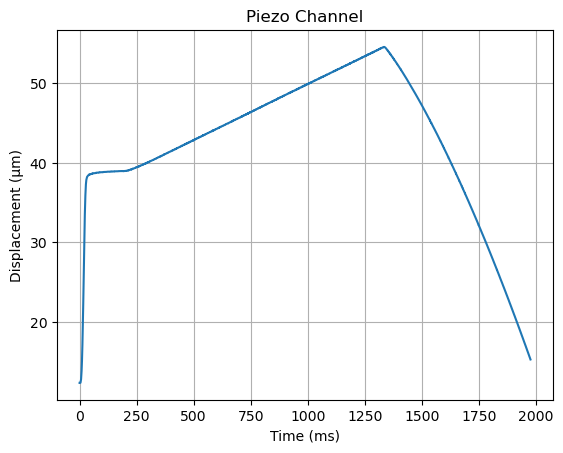

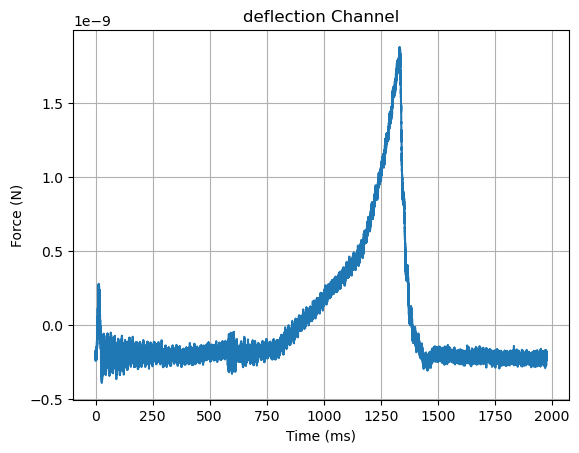

In [13]:
import matplotlib.pyplot as plt

# plot piezo channel vs time
plt.figure()
plt.plot(time_s, piezo_um, label='Piezo Channel (µm)')
plt.title('Piezo Channel')
plt.xlabel('Time (ms)')
plt.ylabel('Displacement (µm)')
plt.grid()
plt.show()

# plot piezo channel vs time
plt.figure()
plt.plot(time_s, deflection_zero_uN, label='Piezo Channel (µm)')
plt.title('deflection Channel')
plt.xlabel('Time (ms)')
plt.ylabel('Force (N)')
plt.grid()
plt.show()

In [14]:
import plotly.graph_objects as go
import plotly.io as pio

pio.templates.default = 'plotly_dark'  # or try 'ggplot2', 'seaborn', etc.
print(pio.templates)

fig = go.Figure()

# Plot deflection vs time
fig.add_trace(go.Scatter(
    x=time_s,
    y=deflection_zero_uN,
    mode='lines',
    name='Deflection (µN)',
    yaxis='y1'  # Link to the first y-axis
))

# Plot piezo vs time
fig.add_trace(go.Scatter(
    x=time_s,
    y=piezo_um,
    mode='lines',
    name='Zstage Piezo (µm)',
    yaxis='y2'  # Link to the second y-axis
))

fig.update_layout(
    title='Fast approach force curve',
    xaxis=dict(
        title='Time (ms)',
        showgrid=True  # Remove x-axis grid
    ),
    yaxis=dict(
        title='Force (µN)',
        tickformat='.2f',
        side='right',
        showgrid=False  # Remove y-axis grid
    ),
    yaxis2=dict(
        title='Displacement (µm)',
        overlaying='y',
        side='left',
        showgrid=True  # Remove secondary y-axis grid
    ),
    legend=dict(x=0.01, y=0.99),
    width=1000,
    height=600,
    paper_bgcolor='rgba(0,0,0,0)',  # Transparent background
    plot_bgcolor='rgba(0,0,0,0)'    # Transparent plot area
)

fig.show()


Templates configuration
-----------------------
    Default template: 'plotly_dark'
    Available templates:
        ['ggplot2', 'seaborn', 'simple_white', 'plotly',
         'plotly_white', 'plotly_dark', 'presentation', 'xgridoff',
         'ygridoff', 'gridon', 'none']



In [15]:
import plotly.graph_objects as go
import plotly.io as pio

pio.templates.default = 'plotly_dark'  # or try 'ggplot2', 'seaborn', etc.
print(pio.templates)

fig = go.Figure()

# Plot deflection vs time
fig.add_trace(go.Scatter(
    x=time_s,
    y=deflection_zero_uN,
    mode='lines',
    name='Deflection (µN)',
    yaxis='y1'  # Link to the first y-axis
))

# Plot piezo vs time
fig.add_trace(go.Scatter(
    x=time_s,
    y=piezo_um,
    mode='lines',
    name='Zstage Piezo (µm)',
    yaxis='y2'  # Link to the second y-axis
))

fig.update_layout(
    title='Fast approach force curve',
    xaxis=dict(
        title='Time (ms)',
        showgrid=True  # Remove x-axis grid
    ),
    yaxis=dict(
        title='Force (N)',
        tickformat='.2f',
        side='right',
        showgrid=False  # Remove y-axis grid
    ),
    yaxis2=dict(
        title='Displacement (µm)',
        overlaying='y',
        side='left',
        showgrid=True  # Remove secondary y-axis grid
    ),
    legend=dict(x=0.01, y=0.99),
    width=1000,
    height=600,
    paper_bgcolor='black',  # Black background
    plot_bgcolor='black'    # Black plot area
)

fig.show()


Templates configuration
-----------------------
    Default template: 'plotly_dark'
    Available templates:
        ['ggplot2', 'seaborn', 'simple_white', 'plotly',
         'plotly_white', 'plotly_dark', 'presentation', 'xgridoff',
         'ygridoff', 'gridon', 'none']

